In [ ]:
import pandas as pd

df = pd.read_csv('Electric_Vehicle_Charging_Station_Data_-4748264627261459144.csv')
print(df.shape)
df.head()

(148136, 17)


,Station_Name,Address,City,State_Province,Zip_Postal_Code,Start_Date___Time,Start_Time_Zone,End_Date___Time,End_Time_Zone,Total_Duration__hh_mm_ss_,Charging_Time__hh_mm_ss_,Energy__kWh_,GHG_Savings__kg_,Gasoline_Savings__gallons_,Port_Type,ObjectID,ObjectId2
0,BOULDER / JUNCTION ST1,2280 Junction Pl,Boulder,Colorado,80301,1/1/2018 17:49,MDT,1/1/2018 19:52,MDT,2:03:02,2:02:44,6.504,2.732,0.816,Level 2,0,1
1,BOULDER / JUNCTION ST1,2280 Junction Pl,Boulder,Colorado,80301,1/2/2018 8:52,MDT,1/2/2018 9:16,MDT,0:24:34,0:24:19,2.481,1.042,0.311,Level 2,1,2
2,BOULDER / JUNCTION ST1,2280 Junction Pl,Boulder,Colorado,80301,1/2/2018 21:11,MDT,1/3/2018 6:23,MDT,9:12:21,3:40:52,15.046,6.319,1.888,Level 2,2,3
3,BOULDER / ALPINE ST1,1275 Alpine Ave,Boulder,Colorado,80304,1/3/2018 9:19,MDT,1/3/2018 11:14,MDT,1:54:51,1:54:29,6.947,2.918,0.872,Level 2,3,4
4,BOULDER / BASELINE ST1,900 Baseline Rd,Boulder,Colorado,80302,1/3/2018 14:13,MDT,1/3/2018 14:30,MDT,0:16:58,0:16:44,1.800,0.756,0.226,Level 2,4,5


In [ ]:
import sqlite3

In [ ]:
print("All columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

All columns:
['Station_Name', 'Address', 'City', 'State_Province', 'Zip_Postal_Code', 'Start_Date___Time', 'Start_Time_Zone', 'End_Date___Time', 'End_Time_Zone', 'Total_Duration__hh_mm_ss_', 'Charging_Time__hh_mm_ss_', 'Energy__kWh_', 'GHG_Savings__kg_', 'Gasoline_Savings__gallons_', 'Port_Type', 'ObjectID', 'ObjectId2']

Data types:
Station_Name                   object
Address                        object
City                           object
State_Province                 object
Zip_Postal_Code                 int64
Start_Date___Time              object
Start_Time_Zone                object
End_Date___Time                object
End_Time_Zone                  object
Total_Duration__hh_mm_ss_      object
Charging_Time__hh_mm_ss_       object
Energy__kWh_                  float64
GHG_Savings__kg_              float64
Gasoline_Savings__gallons_    float64
Port_Type                      object
ObjectID                        int64
ObjectId2                       int64
dtype: object

Mis

In [ ]:
# --- 1. Convert datetime columns ---
df['Start_Date___Time'] = pd.to_datetime(df['Start_Date___Time'], format='mixed')
df['End_Date___Time']   = pd.to_datetime(df['End_Date___Time'], format='mixed')

# --- 2. Convert duration strings to numeric hours ---
def time_str_to_hours(t):
    try:
        parts = str(t).split(':')
        return int(parts[0]) + int(parts[1])/60 + int(parts[2])/3600
    except:
        return None

df['total_duration_hrs'] = df['Total_Duration__hh_mm_ss_'].apply(time_str_to_hours)
df['charging_time_hrs']  = df['Charging_Time__hh_mm_ss_'].apply(time_str_to_hours)

# --- 3. Engineer new features ---
df['session_hour']       = df['Start_Date___Time'].dt.hour
df['day_of_week']        = df['Start_Date___Time'].dt.day_name()
df['month']              = df['Start_Date___Time'].dt.month
df['year']               = df['Start_Date___Time'].dt.year
df['is_weekend']         = df['Start_Date___Time'].dt.dayofweek >= 5

df['avg_charge_rate_kW'] = df.apply(
    lambda r: r['Energy__kWh_'] / r['charging_time_hrs']
    if r['charging_time_hrs'] and r['charging_time_hrs'] > 0 else None, axis=1
)

# --- 4. Remove impossible values ---
df = df[df['Energy__kWh_'] >= 0]
df = df[df['charging_time_hrs'] > 0]
df = df[df['total_duration_hrs'] > 0]
df = df[df['total_duration_hrs'] <= 24]

# --- 5. Verify ---
print("Shape after cleaning:", df.shape)
print("\nSample of new columns:")
print(df[['session_hour','day_of_week','month','is_weekend',
          'charging_time_hrs','total_duration_hrs','avg_charge_rate_kW']].head())

print("\nStats on key columns:")
print(df[['Energy__kWh_','charging_time_hrs',
          'total_duration_hrs','avg_charge_rate_kW']].describe())

Shape after cleaning: (131419, 25)

Sample of new columns:
   session_hour day_of_week  month  is_weekend  charging_time_hrs  \
0            17      Monday      1       False           2.045556   
1             8     Tuesday      1       False           0.405278   
2            21     Tuesday      1       False           3.681111   
3             9   Wednesday      1       False           1.908056   
4            14   Wednesday      1       False           0.278889   

   total_duration_hrs  avg_charge_rate_kW  
0            2.050556            3.179576  
1            0.409444            6.121727  
2            9.205833            4.087353  
3            1.914167            3.640879  
4            0.282778            6.454183  

Stats on key columns:
        Energy__kWh_  charging_time_hrs  total_duration_hrs  \
count  131419.000000      131419.000000       131419.000000   
mean        9.338388           1.892851            2.451577   
std         8.684658           1.563094           

In [ ]:
import sqlite3

# Create database and load cleaned data
conn = sqlite3.connect('ev_fleet.db')
df.to_sql('sessions', conn, if_exists='replace', index=False)

print("Data loaded into SQLite successfully")
print(f"Total rows in DB: {pd.read_sql('SELECT COUNT(*) as total FROM sessions', conn).iloc[0,0]}")

# Test with your first real SQL query
query = """
SELECT
    Station_Name,
    COUNT(*) AS total_sessions,
    ROUND(AVG(Energy__kWh_), 2) AS avg_kwh,
    ROUND(AVG(charging_time_hrs), 2) AS avg_charge_hrs,
    ROUND(AVG(avg_charge_rate_kW), 2) AS avg_rate_kW
FROM sessions
GROUP BY Station_Name
ORDER BY total_sessions DESC
LIMIT 10
"""

station_summary = pd.read_sql(query, conn)
print("\nTop 10 stations by session count:")
print(station_summary)

Data loaded into SQLite successfully
Total rows in DB: 131419

Top 10 stations by session count:
                   Station_Name  total_sessions  avg_kwh  avg_charge_hrs  \
0     BOULDER / N BOULDER REC 1           14471     9.86            2.14   
1        BOULDER / BASELINE ST1           12694     8.83            1.60   
2     BOULDER / CARPENTER PARK1            9703     9.37            1.96   
3            BOULDER / EAST REC            8748     7.17            1.68   
4   COMM VITALITY / 1100WALNUT1            7786     8.72            1.70   
5     BOULDER / CARPENTER PARK2            7498     8.61            1.76   
6  COMM VITALITY / 1104 SPRUCE1            7482     7.96            1.58   
7      BOULDER / REC CENTER ST2            7004    11.24            2.17   
8   COMM VITALITY / 1000WALNUT1            6192    10.34            2.04   
9          BOULDER / ATRIUM ST1            6067     7.47            1.81   

   avg_rate_kW  
0         4.44  
1         5.41  
2         4.66 

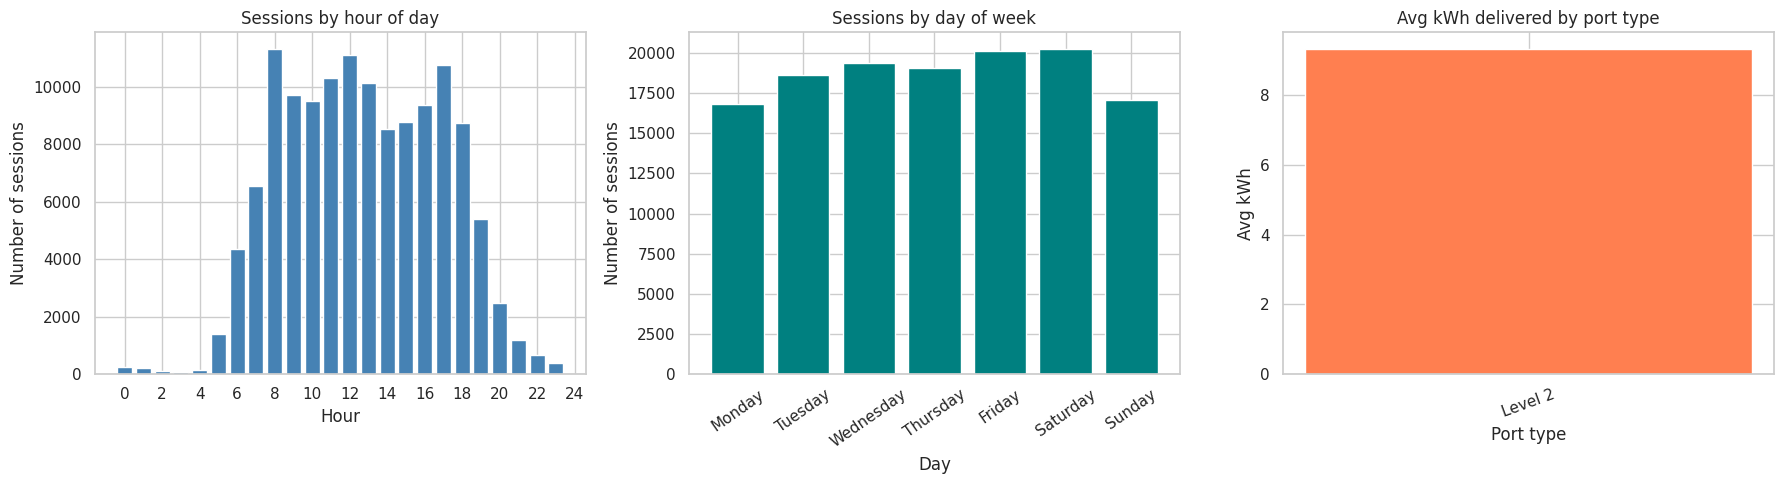


Port type breakdown:
  Port_Type  sessions  avg_kwh  avg_rate_kW
0   Level 2    131419     9.34         4.83


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Chart 1: Sessions by hour of day ---
q1 = """
SELECT session_hour, COUNT(*) as sessions
FROM sessions
GROUP BY session_hour
ORDER BY session_hour
"""
hourly = pd.read_sql(q1, conn)
axes[0].bar(hourly['session_hour'], hourly['sessions'], color='steelblue')
axes[0].set_title('Sessions by hour of day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of sessions')
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(2))

# --- Chart 2: Sessions by day of week ---
q2 = """
SELECT day_of_week, COUNT(*) as sessions
FROM sessions
GROUP BY day_of_week
"""
dow = pd.read_sql(q2, conn)
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow['day_of_week'] = pd.Categorical(dow['day_of_week'], categories=order, ordered=True)
dow = dow.sort_values('day_of_week')
axes[1].bar(dow['day_of_week'], dow['sessions'], color='teal')
axes[1].set_title('Sessions by day of week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of sessions')
axes[1].tick_params(axis='x', rotation=35)

# --- Chart 3: Avg kWh by port type ---
q3 = """
SELECT Port_Type,
       COUNT(*) as sessions,
       ROUND(AVG(Energy__kWh_), 2) as avg_kwh,
       ROUND(AVG(avg_charge_rate_kW), 2) as avg_rate_kW
FROM sessions
GROUP BY Port_Type
ORDER BY avg_kwh DESC
"""
ports = pd.read_sql(q3, conn)
axes[2].bar(ports['Port_Type'], ports['avg_kwh'], color='coral')
axes[2].set_title('Avg kWh delivered by port type')
axes[2].set_xlabel('Port type')
axes[2].set_ylabel('Avg kWh')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('eda_charts_1.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPort type breakdown:")
print(ports)

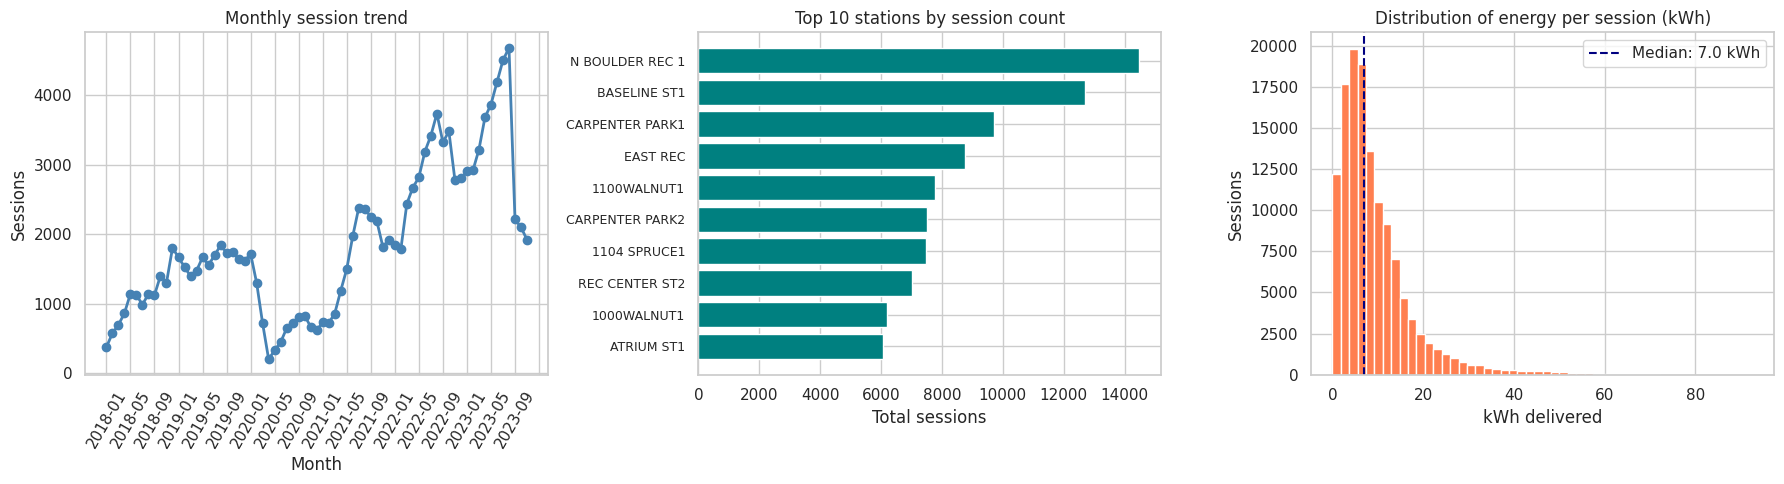

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Chart 4: Monthly session trend (seasonality) ---
q4 = """
SELECT year, month,
       COUNT(*) as sessions,
       ROUND(AVG(Energy__kWh_), 2) as avg_kwh
FROM sessions
GROUP BY year, month
ORDER BY year, month
"""
monthly = pd.read_sql(q4, conn)
monthly['period'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)
axes[0].plot(monthly['period'], monthly['sessions'], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Monthly session trend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Sessions')
axes[0].tick_params(axis='x', rotation=60)
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(4))

# --- Chart 5: Top 10 stations by utilization ---
q5 = """
SELECT Station_Name,
       COUNT(*) as total_sessions,
       ROUND(AVG(total_duration_hrs), 2) as avg_duration_hrs,
       ROUND(AVG(Energy__kWh_), 2) as avg_kwh
FROM sessions
GROUP BY Station_Name
ORDER BY total_sessions DESC
LIMIT 10
"""
top_stations = pd.read_sql(q5, conn)
short_names = [n.replace('BOULDER / ','').replace('COMM VITALITY / ','') for n in top_stations['Station_Name']]
axes[1].barh(short_names[::-1], top_stations['total_sessions'][::-1], color='teal')
axes[1].set_title('Top 10 stations by session count')
axes[1].set_xlabel('Total sessions')
axes[1].tick_params(axis='y', labelsize=9)

# --- Chart 6: Energy distribution ---
q6 = "SELECT Energy__kWh_ FROM sessions WHERE Energy__kWh_ > 0"
energy = pd.read_sql(q6, conn)
axes[2].hist(energy['Energy__kWh_'], bins=50, color='coral', edgecolor='white')
axes[2].set_title('Distribution of energy per session (kWh)')
axes[2].set_xlabel('kWh delivered')
axes[2].set_ylabel('Sessions')
axes[2].axvline(energy['Energy__kWh_'].median(), color='navy',
                linestyle='--', linewidth=1.5, label=f"Median: {energy['Energy__kWh_'].median():.1f} kWh")
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_charts_2.png', dpi=150, bbox_inches='tight')
plt.show()

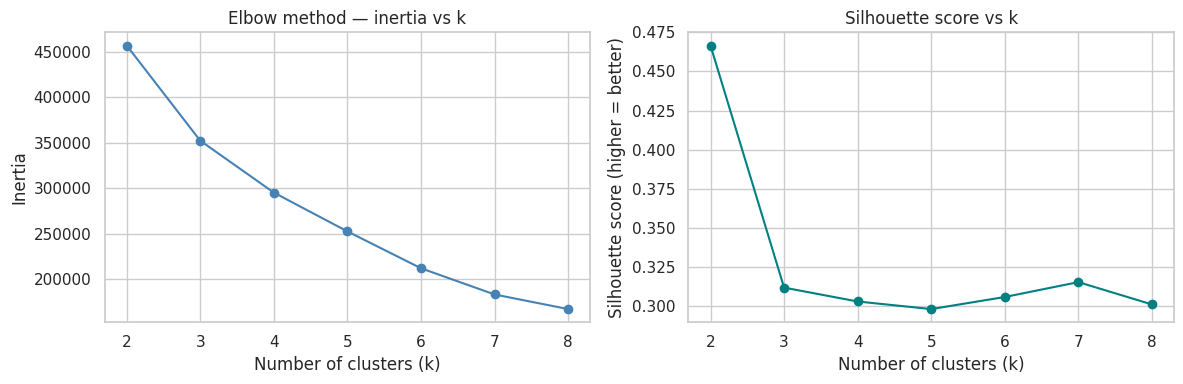


Silhouette scores:
  k=2: 0.4666
  k=3: 0.3116
  k=4: 0.3027
  k=5: 0.2978
  k=6: 0.3056
  k=7: 0.3151
  k=8: 0.3008


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# --- 1. Select features for clustering ---
cluster_features = ['Energy__kWh_', 'charging_time_hrs',
                    'avg_charge_rate_kW', 'session_hour', 'total_duration_hrs']

cluster_df = df[cluster_features].dropna()

# --- 2. Scale features (K-Means is distance-based, scale matters) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

# --- 3. Elbow method to find optimal k ---
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_, sample_size=5000))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow method — inertia vs k')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouettes, marker='o', color='teal')
axes[1].set_title('Silhouette score vs k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score (higher = better)')

plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSilhouette scores:")
for k, s in zip(k_range, silhouettes):
    print(f"  k={k}: {s:.4f}")

         count  avg_kwh  avg_charge_hrs  avg_rate_kW  avg_hour  \
cluster                                                          
0         6113    31.79            6.14         4.93     14.22   
1        54861     7.24            1.20         6.03     13.42   
2        25701    17.40            3.31         5.33     10.50   
3        44744     4.21            1.34         3.06     12.96   

         avg_duration_hrs  pct_of_sessions  
cluster                                     
0                   12.40              4.7  
1                    1.31             41.7  
2                    3.80             19.6  
3                    1.72             34.0  


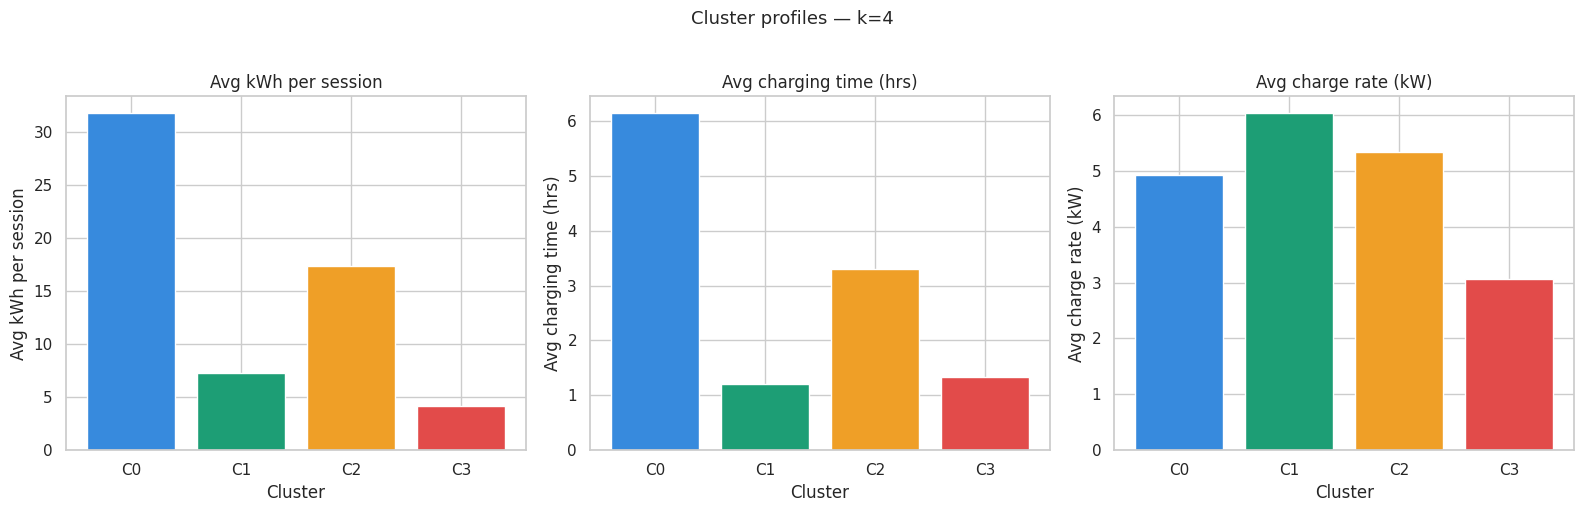

In [ ]:
# --- Fit final model with k=4 ---
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df = df[cluster_features].dropna().copy()
X_scaled = scaler.fit_transform(cluster_df)
cluster_df['cluster'] = km_final.fit_predict(X_scaled)

# Add cluster labels back to main df
df_clustered = df.loc[cluster_df.index].copy()
df_clustered['cluster'] = cluster_df['cluster']

# --- Profile each cluster ---
profile = df_clustered.groupby('cluster').agg(
    count=('Energy__kWh_', 'count'),
    avg_kwh=('Energy__kWh_', 'mean'),
    avg_charge_hrs=('charging_time_hrs', 'mean'),
    avg_rate_kW=('avg_charge_rate_kW', 'mean'),
    avg_hour=('session_hour', 'mean'),
    avg_duration_hrs=('total_duration_hrs', 'mean')
).round(2)

profile['pct_of_sessions'] = (profile['count'] / profile['count'].sum() * 100).round(1)
print(profile)

# --- Visualise cluster profiles ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#378ADD','#1D9E75','#EF9F27','#E24B4A']

metrics = ['avg_kwh', 'avg_charge_hrs', 'avg_rate_kW']
titles  = ['Avg kWh per session', 'Avg charging time (hrs)', 'Avg charge rate (kW)']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    axes[i].bar([f'C{c}' for c in profile.index],
                profile[metric], color=colors)
    axes[i].set_title(title)
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(title)

plt.suptitle('Cluster profiles — k=4', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- Add readable cluster names ---
cluster_names = {
    0: 'Extended Charger',
    1: 'Quick Topper',
    2: 'Mid-Range Charger',
    3: 'Efficiency Seeker'
}
df_clustered['cluster_name'] = df_clustered['cluster'].map(cluster_names)

# --- Define range anxiety flag (Phase 5 target variable) ---
# C0 sessions with high kWh = range anxiety proxy
kwh_85th = df_clustered['Energy__kWh_'].quantile(0.85)
print(f"85th percentile kWh threshold: {kwh_85th:.2f}")

df_clustered['range_anxiety'] = (
    (df_clustered['Energy__kWh_'] >= kwh_85th) &
    (df_clustered['session_hour'].between(6, 21))
).astype(int)

print(f"Range anxiety events: {df_clustered['range_anxiety'].sum():,}")
print(f"Percentage of sessions: {df_clustered['range_anxiety'].mean()*100:.1f}%")

# --- Save enriched CSV for Power BI ---
export_cols = [
    'Station_Name', 'Start_Date___Time', 'session_hour', 'day_of_week',
    'month', 'year', 'is_weekend', 'Energy__kWh_', 'charging_time_hrs',
    'total_duration_hrs', 'avg_charge_rate_kW', 'Port_Type',
    'cluster', 'cluster_name', 'range_anxiety',
    'GHG_Savings__kg_', 'Gasoline_Savings__gallons_'
]

df_clustered[export_cols].to_csv('ev_fleet_cleaned.csv', index=False)
print("\nSaved: ev_fleet_cleaned.csv")
print("Shape:", df_clustered[export_cols].shape)

# --- Also load enriched data into SQLite ---
df_clustered[export_cols].to_sql('sessions_enriched', conn,
                                  if_exists='replace', index=False)
print("Loaded enriched table into SQLite: sessions_enriched")

85th percentile kWh threshold: 15.48
Range anxiety events: 18,960
Percentage of sessions: 14.4%

Saved: ev_fleet_cleaned.csv
Shape: (131419, 17)
Loaded enriched table into SQLite: sessions_enriched


Train: 105,135 | Test: 26,284

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     22492
           1       0.94      0.88      0.91      3792

    accuracy                           0.97     26284
   macro avg       0.96      0.94      0.95     26284
weighted avg       0.97      0.97      0.97     26284

ROC-AUC: 0.9927

--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22492
           1       1.00      1.00      1.00      3792

    accuracy                           1.00     26284
   macro avg       1.00      1.00      1.00     26284
weighted avg       1.00      1.00      1.00     26284

ROC-AUC: 1.0000


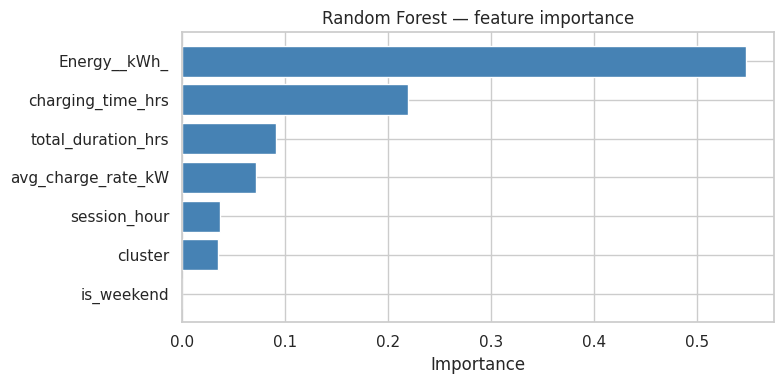

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

feature_cols = ['Energy__kWh_', 'charging_time_hrs', 'avg_charge_rate_kW',
                'session_hour', 'total_duration_hrs', 'is_weekend', 'cluster']

X = df_clustered[feature_cols].dropna()
y = df_clustered.loc[X.index, 'range_anxiety']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])
print("\n--- Logistic Regression ---")
print(classification_report(y_test, lr_preds))
print(f"ROC-AUC: {lr_auc:.4f}")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print("\n--- Random Forest ---")
print(classification_report(y_test, rf_preds))
print(f"ROC-AUC: {rf_auc:.4f}")

# Feature importance
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue')
plt.title('Random Forest — feature importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

--- Logistic Regression (no leakage) ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     22492
           1       0.93      0.88      0.90      3792

    accuracy                           0.97     26284
   macro avg       0.95      0.93      0.94     26284
weighted avg       0.97      0.97      0.97     26284

ROC-AUC: 0.9918

--- Random Forest (no leakage) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22492
           1       1.00      1.00      1.00      3792

    accuracy                           1.00     26284
   macro avg       1.00      1.00      1.00     26284
weighted avg       1.00      1.00      1.00     26284

ROC-AUC: 1.0000


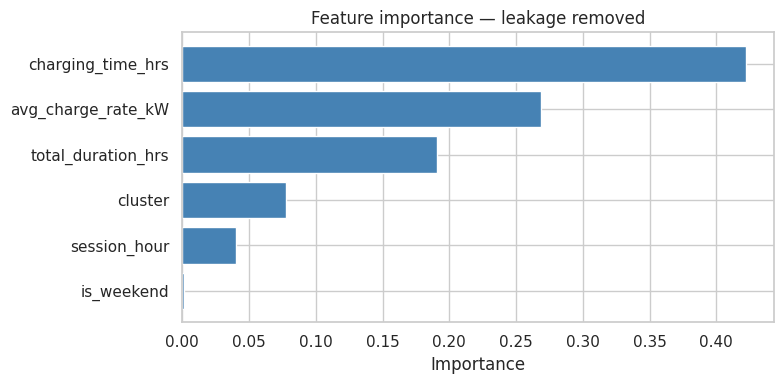

In [ ]:
# --- Fixed model: remove leaky feature ---
feature_cols_fixed = ['charging_time_hrs', 'avg_charge_rate_kW',
                      'session_hour', 'total_duration_hrs',
                      'is_weekend', 'cluster']

X2 = df_clustered[feature_cols_fixed].dropna()
y2 = df_clustered.loc[X2.index, 'range_anxiety']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

# Logistic Regression
lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X_train2, y_train2)
lr2_preds = lr2.predict(X_test2)
lr2_auc = roc_auc_score(y_test2, lr2.predict_proba(X_test2)[:,1])
print("--- Logistic Regression (no leakage) ---")
print(classification_report(y_test2, lr2_preds))
print(f"ROC-AUC: {lr2_auc:.4f}")

# Random Forest
rf2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(X_train2, y_train2)
rf2_preds = rf2.predict(X_test2)
rf2_auc = roc_auc_score(y_test2, rf2.predict_proba(X_test2)[:,1])
print("\n--- Random Forest (no leakage) ---")
print(classification_report(y_test2, rf2_preds))
print(f"ROC-AUC: {rf2_auc:.4f}")

# Feature importance
feat_imp2 = pd.DataFrame({
    'feature': feature_cols_fixed,
    'importance': rf2.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(feat_imp2['feature'], feat_imp2['importance'], color='steelblue')
plt.title('Feature importance — leakage removed')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

High-load stations: ['BOULDER / N BOULDER REC 1', 'BOULDER / BASELINE ST1', 'BOULDER / CARPENTER PARK1']
High stress events: 16,522
Percentage: 12.6%

--- Station stress risk model ---
              precision    recall  f1-score   support

           0       0.87      1.00      0.93     22980
           1       0.69      0.01      0.01      3304

    accuracy                           0.87     26284
   macro avg       0.78      0.50      0.47     26284
weighted avg       0.85      0.87      0.82     26284

ROC-AUC: 0.8435


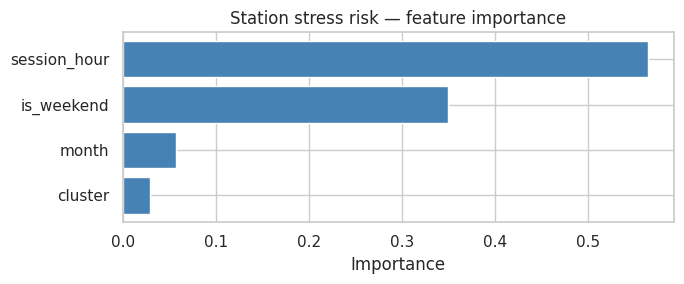

In [ ]:
# --- Redefine target: station + time based risk ---
# High-risk = station in top 3 busiest + peak hour + weekday
# This is a genuine "will this station be overwhelmed?" prediction

busy_stations = station_summary['Station_Name'].head(3).tolist()
print("High-load stations:", busy_stations)

df_clustered['station_stress_risk'] = (
    (df_clustered['Station_Name'].isin(busy_stations)) &
    (df_clustered['session_hour'].between(10, 18)) &
    (~df_clustered['is_weekend'])
).astype(int)

print(f"High stress events: {df_clustered['station_stress_risk'].sum():,}")
print(f"Percentage: {df_clustered['station_stress_risk'].mean()*100:.1f}%")

# Features known BEFORE session starts
feature_cols_v3 = ['session_hour', 'is_weekend', 'cluster', 'month']

X3 = df_clustered[feature_cols_v3].dropna()
y3 = df_clustered.loc[X3.index, 'station_stress_risk']

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3)

rf3 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf3.fit(X_train3, y_train3)
rf3_preds = rf3.predict(X_test3)
rf3_auc = roc_auc_score(y_test3, rf3.predict_proba(X_test3)[:,1])

print("\n--- Station stress risk model ---")
print(classification_report(y_test3, rf3_preds))
print(f"ROC-AUC: {rf3_auc:.4f}")

feat_imp3 = pd.DataFrame({
    'feature': feature_cols_v3,
    'importance': rf3.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(7, 3))
plt.barh(feat_imp3['feature'], feat_imp3['importance'], color='steelblue')
plt.title('Station stress risk — feature importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance_v3.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Add predictions to the dataframe
df_clustered['stress_risk_pred'] = rf3.predict(
    df_clustered[feature_cols_v3].fillna(0))
df_clustered['stress_risk_proba'] = rf3.predict_proba(
    df_clustered[feature_cols_v3].fillna(0))[:,1]

# Final export with all columns Power BI needs
final_export_cols = [
    'Station_Name', 'Start_Date___Time', 'session_hour', 'day_of_week',
    'month', 'year', 'is_weekend', 'Energy__kWh_', 'charging_time_hrs',
    'total_duration_hrs', 'avg_charge_rate_kW', 'Port_Type',
    'cluster', 'cluster_name', 'range_anxiety',
    'station_stress_risk', 'stress_risk_pred', 'stress_risk_proba',
    'GHG_Savings__kg_', 'Gasoline_Savings__gallons_'
]

df_final = df_clustered[final_export_cols].copy()
df_final.to_csv('ev_fleet_final.csv', index=False)

print("Final export saved: ev_fleet_final.csv")
print("Shape:", df_final.shape)
print("\nColumns in final file:")
print(df_final.columns.tolist())
print("\nSample:")
print(df_final.head(3))

Final export saved: ev_fleet_final.csv
Shape: (131419, 20)

Columns in final file:
['Station_Name', 'Start_Date___Time', 'session_hour', 'day_of_week', 'month', 'year', 'is_weekend', 'Energy__kWh_', 'charging_time_hrs', 'total_duration_hrs', 'avg_charge_rate_kW', 'Port_Type', 'cluster', 'cluster_name', 'range_anxiety', 'station_stress_risk', 'stress_risk_pred', 'stress_risk_proba', 'GHG_Savings__kg_', 'Gasoline_Savings__gallons_']

Sample:
             Station_Name   Start_Date___Time  session_hour day_of_week  \
0  BOULDER / JUNCTION ST1 2018-01-01 17:49:00            17      Monday   
1  BOULDER / JUNCTION ST1 2018-01-02 08:52:00             8     Tuesday   
2  BOULDER / JUNCTION ST1 2018-01-02 21:11:00            21     Tuesday   

   month  year  is_weekend  Energy__kWh_  charging_time_hrs  \
0      1  2018       False         6.504           2.045556   
1      1  2018       False         2.481           0.405278   
2      1  2018       False        15.046           3.681111   

  